# Desafío - Inferencia e hipótesis

Podemos registrar muchas características de una persona, y buscar ver si algunas influyen o
no en otras. Realiza las siguientes actividades para verificarlo.
1. Considerando las variables earn, height y age, vamos a suponer que nuestro dataset
fuera una población completa. (Prepara los datos adecuadamente).
- a. Realiza 12 pruebas (4 por cada variable) con muestras de tamaño n = 25, en
cada caso, con niveles de significancia diferentes pero inferiores a 0,1, para
confirmar o rechazar las siguientes hipótesis considerando las alternativas.
Crea para ello una fórmula que reciba los parámetros adecuados y responda
"con nivel de confianza del ...%, se acepta la hipótesis nula/alternativa".

- b. Calcula la media poblacional para cada variable. ¿Son correctos los
resultados obtenidos por tus pruebas?

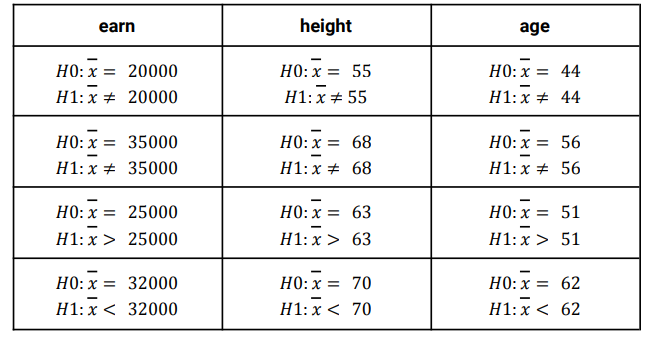

In [1]:
# Primero vamos a importamos la librería pandas.
import pandas as pd

# Creamos el dataframe usando 'pd.read_csv()'.
df= pd.read_csv('earnings.csv',delimiter=',')

# Mostramos el dataframe creado.
df

,height,weight,male,earn,earnk,ethnicity,education,mother_education,father_education,walk,exercise,smokenow,tense,angry,age
0,74,210.0,1,50000.0,50.0,White,16.0,16.0,16.0,3,3,2.0,0.0,0.0,45
1,66,125.0,0,60000.0,60.0,White,16.0,16.0,16.0,6,5,1.0,0.0,0.0,58
2,64,126.0,0,30000.0,30.0,White,16.0,16.0,16.0,8,1,2.0,1.0,1.0,29
3,65,200.0,0,25000.0,25.0,White,17.0,17.0,NaN,8,1,2.0,0.0,0.0,57
4,63,110.0,0,50000.0,50.0,Other,16.0,16.0,16.0,5,6,2.0,0.0,0.0,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1811,61,120.0,0,15000.0,15.0,White,18.0,18.0,18.0,6,1,2.0,0.0,0.0,82
1812,64,130.0,0,8000.0,8.0,White,12.0,12.0,12.0,1,1,1.0,7.0,7.0,33
1813,72,194.0,1,60000.0,60.0,White,12.0,12.0,12.0,2,1,2.0,0.0,0.0,50
1814,63,155.0,0,15000.0,15.0,Other,14.0,14.0,14.0,6,1,2.0,2.0,2.0,69


In [4]:
# Vamos a explorar el dataframe y ver un resumen estadístico.
df.columns

Index(['height', 'weight', 'male', 'earn', 'earnk', 'ethnicity', 'education',
       'mother_education', 'father_education', 'walk', 'exercise', 'smokenow',
       'tense', 'angry', 'age'],
      dtype='object')

In [2]:
df.describe(include="all")

,height,weight,male,earn,earnk,ethnicity,education,mother_education,father_education,walk,exercise,smokenow,tense,angry,age
count,1816.000000,1789.000000,1816.000000,1816.000000,1816.000000,1816,1814.000000,1572.000000,1521.000000,1816.000000,1816.000000,1815.000000,1815.000000,1815.000000,1816.000000
unique,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,White,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,1494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,66.568833,156.305198,0.371696,21147.296256,21.147296,NaN,13.235391,13.608779,13.652202,5.303414,3.049009,1.745455,1.421488,1.421488,42.934471
std,3.831822,34.617059,0.483391,22531.765123,22.531765,NaN,2.556638,3.219372,3.250811,2.601104,2.316385,0.435725,2.157850,2.157850,17.161672
min,57.000000,80.000000,0.000000,0.000000,0.000000,NaN,2.000000,3.000000,3.000000,1.000000,1.000000,1.000000,0.000000,0.000000,18.000000
25%,64.000000,130.000000,0.000000,6000.000000,6.000000,NaN,12.000000,12.000000,12.000000,3.000000,1.000000,1.000000,0.000000,0.000000,29.000000
50%,66.000000,150.000000,0.000000,16000.000000,16.000000,NaN,12.000000,13.000000,13.000000,6.000000,2.000000,2.000000,0.000000,0.000000,39.000000
75%,69.250000,180.000000,1.000000,27000.000000,27.000000,NaN,15.000000,16.000000,16.000000,8.000000,5.000000,2.000000,2.000000,2.000000,56.000000


In [6]:
# Revisamos duplicados.
df.duplicated().sum()

np.int64(0)

In [10]:
# Mostramos el tipo de dato y nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1816 entries, 0 to 1815
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   height            1816 non-null   int64  
 1   weight            1789 non-null   float64
 2   male              1816 non-null   int64  
 3   earn              1816 non-null   float64
 4   earnk             1816 non-null   float64
 5   ethnicity         1816 non-null   object 
 6   education         1814 non-null   float64
 7   mother_education  1572 non-null   float64
 8   father_education  1521 non-null   float64
 9   walk              1816 non-null   int64  
 10  exercise          1816 non-null   int64  
 11  smokenow          1815 non-null   float64
 12  tense             1815 non-null   float64
 13  angry             1815 non-null   float64
 14  age               1816 non-null   int64  
dtypes: float64(9), int64(5), object(1)
memory usage: 212.9+ KB


In [3]:
# Borramos los nulos y seleccionamos las columnas necesarias para poder comenzar a trabajar (Creamos un nuevo df).
df_limpio = df[['earn', 'height', 'age', 'male']].dropna().copy()

# Mostramos el df limpio.
df_limpio

,earn,height,age,male
0,50000.0,74,45,1
1,60000.0,66,58,0
2,30000.0,64,29,0
3,25000.0,65,57,0
4,50000.0,63,91,0
...,...,...,...,...
1811,15000.0,61,82,0
1812,8000.0,64,33,0
1813,60000.0,72,50,1
1814,15000.0,63,69,0


In [4]:
# Importamos las librerías necesarias.
import numpy as np
from scipy import stats
import math
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Función para hacer las puebas de hipotesis.
def one_sample_test(data, var, mu0, alternative='two-sided',
                    n=25, alpha=0.05, seed=42): # seed=42 hace que la muestra sea reproducible.
    """
    Toma una muestra aleatoria de tamaño n de la variable var,
    realiza un test t y devuelve resultados + interpretación.
    """

    # Muestra aleatoria sin reemplazo.
    sample = data[var].dropna().sample(n=n, random_state=seed)

    xbar = sample.mean()
    s = sample.std(ddof=1)

    # Test t de una muestra.
    t_stat, p_two = stats.ttest_1samp(sample, popmean=mu0)

    # Ajuste según alternativa.
    if alternative == 'two-sided':
        p_value = p_two
    elif alternative == 'greater':      # H1: μ > μ0
        p_value = stats.t.sf(t_stat, df=n-1)
    elif alternative == 'less':         # H1: μ < μ0
        p_value = stats.t.cdf(t_stat, df=n-1)
    else:
        raise ValueError("alternative debe ser: two-sided, greater, less")

    # Interpretación.
    conf_level = (1 - alpha) * 100
    if p_value >= alpha:
        conclusion = f"Con nivel de confianza del {conf_level:.1f}%, se acepta la hipótesis nula."
    else:
        conclusion = f"Con nivel de confianza del {conf_level:.1f}%, se rechaza la hipótesis nula a favor de la alternativa."

    # Estadísticos importantes del test t dentro de un diccionario de Python.
    return {
        'variable': var,
        'mu0': mu0,
        'alternative': alternative,
        'sample_mean': xbar,
        'sample_std': s,
        't_stat': t_stat,
        'p_value': p_value,
        'alpha': alpha,
        'conclusion': conclusion
    }

In [6]:
# Creamos una lista con las pruebas solicitadas.
tests = [
    # earn
    ('earn', 20000, 'two-sided', 0.05),
    ('earn', 35000, 'two-sided', 0.01),
    ('earn', 25000, 'greater',    0.08),
    ('earn', 32000, 'less',       0.03),

    # height
    ('height', 55, 'two-sided', 0.04),
    ('height', 68, 'two-sided', 0.02),
    ('height', 63, 'greater',    0.07),
    ('height', 70, 'less',       0.06),

    # age
    ('age', 44, 'two-sided', 0.05),
    ('age', 56, 'two-sided', 0.01),
    ('age', 51, 'greater',    0.08),
    ('age', 62, 'less',       0.03),
]

# Ejecutamos las pruebas.
results = []
for i, (var, mu0, alt, alpha) in enumerate(tests, start=1):
    res = one_sample_test(df_limpio, var, mu0,
                          alternative=alt, alpha=alpha, seed=100+i)
    results.append(res)

# Mostramos los resultados.
results_df = pd.DataFrame(results)
print("\n===== Resultados de las pruebas =====")
results_df


===== Resultados de las pruebas =====


,variable,mu0,alternative,sample_mean,sample_std,t_stat,p_value,alpha,conclusion
0,earn,20000,two-sided,21440.00,13422.090001,0.536429,5.965998e-01,0.05,"Con nivel de confianza del 95.0%, se acepta la..."
1,earn,35000,two-sided,20420.00,21270.911280,-3.427216,2.204910e-03,0.01,"Con nivel de confianza del 99.0%, se rechaza l..."
2,earn,25000,greater,13816.00,10180.564817,-5.492819,9.999940e-01,0.08,"Con nivel de confianza del 92.0%, se acepta la..."
3,earn,32000,less,24440.00,25182.798362,-1.501025,7.319595e-02,0.03,"Con nivel de confianza del 97.0%, se acepta la..."
4,height,55,two-sided,66.80,3.894440,15.149801,8.742540e-14,0.04,"Con nivel de confianza del 96.0%, se rechaza l..."
5,height,68,two-sided,66.84,3.738092,-1.551594,1.338476e-01,0.02,"Con nivel de confianza del 98.0%, se acepta la..."
6,height,63,greater,66.88,4.521430,4.290678,1.261022e-04,0.07,"Con nivel de confianza del 93.0%, se rechaza l..."
7,height,70,less,68.04,3.878144,-2.526982,9.253022e-03,0.06,"Con nivel de confianza del 94.0%, se rechaza l..."
8,age,44,two-sided,44.36,21.658101,0.083110,9.344536e-01,0.05,"Con nivel de confianza del 95.0%, se acepta la..."
9,age,56,two-sided,38.12,15.870098,-5.633236,8.450524e-06,0.01,"Con nivel de confianza del 99.0%, se rechaza l..."


In [46]:
# Calculamos las medias poblacionales de cada variable.
medias_poblacionales = df_limpio[['earn', 'height', 'age']].mean()

# Mostramos los resultados.
print("\n===== Medias Poblacionales=====")
medias_poblacionales


===== Medias Poblacionales=====


earn      21147.296256
height       66.568833
age          42.934471
dtype: float64

#### ¿Son correctos los resultados obtenidos por las pruebas?
Sí, los resultados son correctos. En todos los casos, las conclusiones del test t coinciden con lo que se espera al comparar las medias muestrales con las medias reales del dataset.
- earn: Las muestras quedan bastante alejadas de varios valores propuestos en H₀, por eso algunas pruebas rechazan y otras no rechazan la hipótesis. Todas las decisiones son coherentes con que la media real ronda valores más altos que los μ₀ planteados.
- height: Las muestras se concentran cerca de ~66.8 pulgadas. Cuando μ₀ es muy distinto (como 55 o 70) se rechaza H₀; cuando es cercano (como 68) no se rechaza. Todo es consistente con la media real.
- age: Las muestras rondan los 40–44 años. Valores de μ₀ muy superiores (56 o 62) llevan al rechazo de H₀, mientras que μ₀ cercanos a la media real no se rechazan. También coherente.
**En resumen, cada prueba tomó la decisión que corresponde según la diferencia entre el valor hipotético y la media real, considerando el tamaño muestral y la variabilidad. No se observan resultados inconsistentes o contradictorios.** 

 2. Crea una función que estime la proporción de hombres en el dataset, considerando
una muestra de 50 individuos, con niveles de significancia de 0,05 y 0,01. Escribe con
palabras tus resultados ejecutar la función e interpreta. Compara con la proporción
real.

In [30]:
# Función para estimar la proporción de hombres.
def proportion_estimate(data, male_col='male', n=50, alphas=[0.05, 0.01], seed=42):
    #Toma de la muestra.
    sample = data[male_col].sample(n=n, random_state=seed)
    #Proporción muestral.
    phat = sample.mean()
    #Diccionario para guardar resultados.
    results = {'phat': phat, 'intervalos': {}} 

    #Cálculo de los intervalos de confianza.
    for alpha in alphas:
        #Valor crítico Z.
        z = stats.norm.ppf(1 - alpha/2)
        #Error estándar de la proporción.
        se = math.sqrt(phat * (1 - phat) / n)
        #Límites del intervalo.
        lower = phat - z * se
        upper = phat + z * se
        results['intervalos'][alpha] = (max(0, lower), min(1, upper))

    results['población_real'] = data[male_col].mean()
    return results


===== Estimación de proporción de hombres =====
Proporción muestral (phat): 0.540
Proporción real población: 0.372
IC 95%: (0.402, 0.678)
IC 99%: (0.358, 0.722)


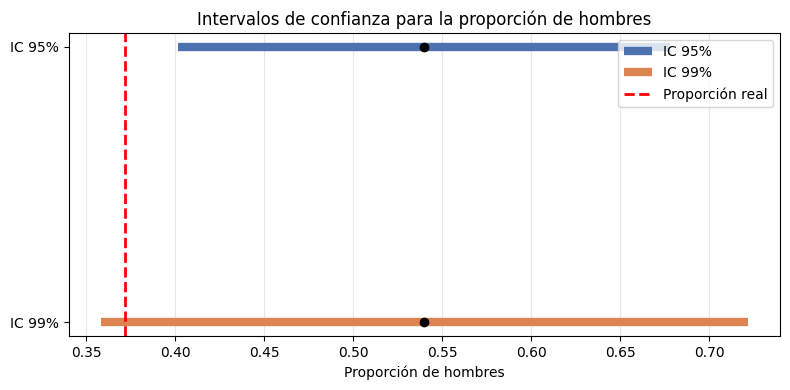

In [37]:
# Calculamos la proporción.
prop_result = proportion_estimate(df_limpio)

# Imprimimos los resultados.
print("\n===== Estimación de proporción de hombres =====")
print(f"Proporción muestral (phat): {prop_result['phat']:.3f}")
print(f"Proporción real población: {prop_result['población_real']:.3f}")

#Intervalos de confianza.
for alpha, intervalo in prop_result['intervalos'].items():
    print(f"IC {(1-alpha)*100:.0f}%: ({intervalo[0]:.3f}, {intervalo[1]:.3f})")

# Extraemos los valores para realizar el gráfico.
phat = prop_result['phat']
ic_95 = prop_result['intervalos'][0.05]
ic_99 = prop_result['intervalos'][0.01]
p_real = prop_result['población_real']

# Graficamos.
plt.figure(figsize=(8, 4))

# IC 95%
plt.hlines(
    y=1,
    xmin=ic_95[0],
    xmax=ic_95[1],
    linewidth=6,
    label="IC 95%",
    color="#4C72B0"
)
plt.plot(phat, 1, 'o', color="black")

# IC 99%
plt.hlines(
    y=0,
    xmin=ic_99[0],
    xmax=ic_99[1],
    linewidth=6,
    label="IC 99%",
    color="#DD8452"
)
plt.plot(phat, 0, 'o', color="black")

# Proporción real
plt.axvline(
    p_real,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Proporción real"
)

plt.yticks([0, 1], ["IC 99%", "IC 95%"])
plt.xlabel("Proporción de hombres")
plt.title("Intervalos de confianza para la proporción de hombres")
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### Conclusión:
A partir de una muestra aleatoria de 50 individuos se estimó la proporción de hombres en el dataset, obteniéndose una proporción muestral p^=0.54. Se construyeron intervalos de confianza al 95% y 99%.
El intervalo al 95% no contiene la proporción real poblacional (≈ 0.37), lo que indica que, con ese nivel de confianza, la estimación muestral no resulta consistente con el valor real. En cambio, el intervalo al 99%, más amplio, sí contiene la proporción poblacional, lo cual es coherente con el mayor nivel de confianza asociado a este intervalo.
El gráfico de la proporción estimada junto con los intervalos de confianza permite visualizar claramente esta situación: se observa que el valor poblacional queda fuera del intervalo al 95%, pero dentro del intervalo al 99%. Esto refuerza la idea de que, al aumentar el nivel de confianza, se incrementa la probabilidad de contener el parámetro real, a costa de una menor precisión.

 3. Considerando el dataset como una muestra, verifica si el género (male=1 significa
‘hombre”) influye sobre el sueldo “earn” de las personas. Explica y justifica tu
procedimiento.

In [19]:
# ¿El género influye en el sueldo ('earn')?

# Separamos los grupos.
group_m = df_limpio[df_limpio['male'] == 1]['earn'] # Hombres
group_f = df_limpio[df_limpio['male'] == 0]['earn'] # Mujeres

# Calculamos promedios.
mean_men = group_m .mean()
mean_women = group_f.mean()

# Test t para dos muestras independientes.
t_stat, p_value = stats.ttest_ind(group_m, group_f,
                                  equal_var=equal_var)

print("\n===== TEST PARA VER SI EL GÉNERO INFLUYE EN EL SUELDO =====")
print(f"t={t_stat:.4f}, p={p_value:.6f}")
print(f"Media hombres: {group_m.mean():.2f}")
print(f"Media mujeres: {group_f.mean():.2f}")

# Interpretación.
alpha = 0.05
if p_value < alpha:
    print("Conclusión: Hay evidencia estadística de que el género influye en el sueldo.")
else:
    print("Conclusión: No hay evidencia suficiente para afirmar que el género influye.")


===== TEST PARA VER SI EL GÉNERO INFLUYE EN EL SUELDO =====
t=11.8646, p=0.000000
Media hombres: 30105.18
Media mujeres: 15847.94
Conclusión: Hay evidencia estadística de que el género influye en el sueldo.


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_20028\745593204.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


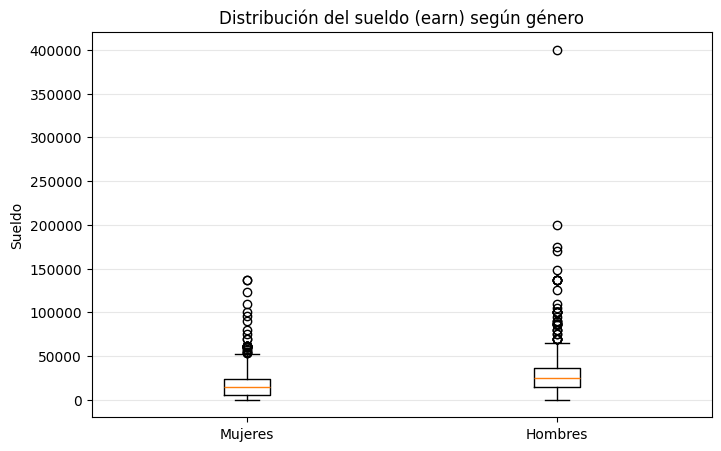

In [20]:
# Gráfico boxplot.
plt.figure(figsize=(8, 5))

plt.boxplot(
    [group_f, group_m],
    labels=['Mujeres', 'Hombres'],
    showfliers=True
)

plt.title('Distribución del sueldo (earn) según género')
plt.ylabel('Sueldo')
plt.grid(axis='y', alpha=0.3)
plt.show()

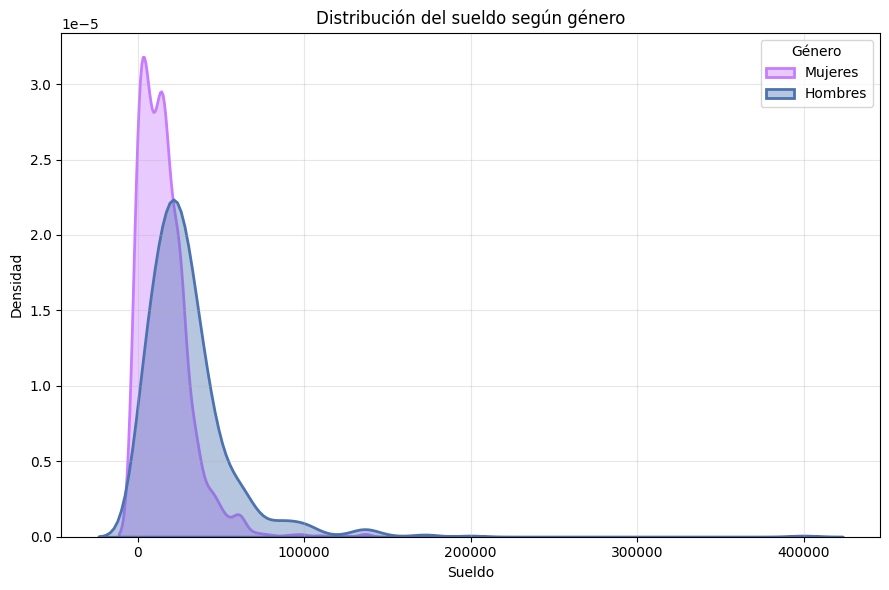

In [28]:
# Gráfico de densidad. 
plt.figure(figsize=(9, 6))

sns.kdeplot(
    x=salaries_women,
    label="Mujeres",
    fill=True,
    alpha=0.4,
    linewidth=2,
    color="#C77CFF"   
)
sns.kdeplot(
    x=salaries_men,
    label="Hombres",
    fill=True,
    alpha=0.4,
    linewidth=2,
    color="#4C72B0" 
)
plt.title("Distribución del sueldo según género")
plt.xlabel("Sueldo")
plt.ylabel("Densidad")
plt.legend(title="Género")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretación de los resultados:
- Para analizar si el género influye sobre el sueldo (earn), se realizó un test t para dos muestras independientes, comparando los ingresos promedio de hombres y mujeres.Los resultados obtenidos muestran un estadístico t=11.8646 con un valor p prácticamente nulo (p<0.001). Al trabajar con un nivel de significancia del 5%, se rechaza la hipótesis nula de igualdad de medias.Además, se observa que el ingreso promedio de los hombres (30 105.18) es considerablemente mayor que el de las mujeres (15 847.94). 
- El boxplot muestra que la distribución de sueldos de los hombres se encuentra desplazada hacia valores más altos que la de las mujeres. Tanto la mediana como los cuartiles son mayores en el grupo masculino, lo que respalda visualmente el resultado del test t.
- El gráfico de densidad muestra que la distribución de sueldos de los hombres se encuentra claramente desplazada hacia valores más altos en comparación con la de las mujeres. La mayor concentración de ingresos masculinos se da en rangos salariales superiores, mientras que la densidad correspondiente a las mujeres se concentra en valores más bajos. Este comportamiento visual es consistente con la diferencia observada en los promedios y con el resultado significativo del test t realizado.

**En consecuencia, existe evidencia estadísticamente significativa para afirmar que el género influye sobre el sueldo en el conjunto de datos analizado.**